In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import radians, sin, cos, sqrt, atan2
import warnings
warnings.filterwarnings('ignore')

# Настройки отображения
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

# Стиль графиков
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

DATA_DIR = 'data'
RANDOM_SEED = 42

In [3]:
train_traffic = pd.read_csv(f'{DATA_DIR}/train/traffic.csv')
train_schedule = pd.read_csv(f'{DATA_DIR}/train/schedule.csv')
train_labels = pd.read_csv(f'{DATA_DIR}/labels/labels_train.csv')

test_traffic = pd.read_csv(f'{DATA_DIR}/test/traffic.csv')
test_schedule = pd.read_csv(f'{DATA_DIR}/test/schedule.csv')
test_labels = pd.read_csv(f'{DATA_DIR}/labels/labels_test.csv')

val_traffic = pd.read_csv(f'{DATA_DIR}/validate/traffic.csv')
val_schedule = pd.read_csv(f'{DATA_DIR}/validate/schedule_plan.csv')
val_points = pd.read_csv(f'{DATA_DIR}/validate/points.csv')

sample_sub = pd.read_csv(f'{DATA_DIR}/sample_submission.csv', sep=';')

print('=== РАЗМЕРЫ ФАЙЛОВ ===')
print(f'Train traffic:    {train_traffic.shape}')
print(f'Train schedule:   {train_schedule.shape}')
print(f'Train labels:     {train_labels.shape}')
print(f'Test traffic:     {test_traffic.shape}')
print(f'Test schedule:    {test_schedule.shape}')
print(f'Test labels:      {test_labels.shape}')
print(f'Val traffic:      {val_traffic.shape}')
print(f'Val schedule:     {val_schedule.shape}')
print(f'Val points:       {val_points.shape}')
print(f'Sample submission: {sample_sub.shape}')

=== РАЗМЕРЫ ФАЙЛОВ ===
Train traffic:    (287849, 14)
Train schedule:   (16674, 8)
Train labels:     (4434, 8)
Test traffic:     (105945, 14)
Test schedule:    (5558, 8)
Test labels:      (353, 8)
Val traffic:      (105945, 14)
Val schedule:     (5558, 7)
Val points:       (151, 6)
Sample submission: (151, 2)


In [4]:
def describe_df(df, name):
    print(f'\n{"="*60}')
    print(f'  {name}')
    print(f'{"="*60}')
    print(f'Shape: {df.shape}')
    print(f'\nКолонки и типы:')
    print(df.dtypes)
    print(f'\nПропуски:')
    miss = df.isnull().sum()
    miss = miss[miss > 0]
    if len(miss) > 0:
        print(miss)
    else:
        print('Нет пропусков')
    print(f'\nПервые 3 строки:')
    display(df.head(3))

describe_df(train_traffic, 'TRAIN TRAFFIC')
describe_df(train_schedule, 'TRAIN SCHEDULE')
describe_df(train_labels, 'TRAIN LABELS')


  TRAIN TRAFFIC
Shape: (287849, 14)

Колонки и типы:
packet_id           object
tr_id                int64
unit_id              int64
event_time          object
device_event_id      int64
location_valid        bool
gps_time            object
lon                float64
lat                float64
alt                float64
speed              float64
heading            float64
receive_time        object
is_hist_data          bool
dtype: object

Пропуски:
gps_time    16499
lon         16499
lat         16499
alt         16499
speed       16499
heading     16499
dtype: int64

Первые 3 строки:


,packet_id,tr_id,unit_id,event_time,device_event_id,location_valid,gps_time,lon,lat,alt,speed,heading,receive_time,is_hist_data
0,-5517330596515664264,115106,664030,2026-01-06 12:30:31.462764,0,False,NaN,NaN,NaN,NaN,NaN,NaN,2026-01-06 12:30:31.462771,False
1,-5517330596515614428,116057,794446,2026-01-06 12:32:00.058242,0,False,NaN,NaN,NaN,NaN,NaN,NaN,2026-01-06 12:32:00.058249,False
2,-5517330596515667265,116445,663271,2026-01-06 12:30:26.176861,0,False,NaN,NaN,NaN,NaN,NaN,NaN,2026-01-06 12:30:26.176865,False



  TRAIN SCHEDULE
Shape: (16674, 8)

Колонки и типы:
tt_action_item_id     int64
time_begin           object
time_fact_begin      object
order_date           object
manual_fill            bool
tr_id                 int64
geom                 object
building_address     object
dtype: object

Пропуски:
building_address    2925
dtype: int64

Первые 3 строки:


,tt_action_item_id,time_begin,time_fact_begin,order_date,manual_fill,tr_id,geom,building_address
0,53699433970,2026-01-06 06:36:00.000000000,2026-01-06 06:39:01.000000000,2026-01-06,True,122658,POINT (37.43070705 55.8040083),"Строгинское ш., д.1"
1,53699433974,2026-01-06 06:41:00.000000000,2026-01-06 06:44:01.000000000,2026-01-06,True,122658,POINT (37.46330869 55.80892705),"ул. Маршала Василевского, д.17"
2,53699433972,2026-01-06 06:38:00.000000000,2026-01-06 06:41:01.000000000,2026-01-06,True,122658,POINT (37.45439344 55.80550491),"Новощукинская ул., д.7"



  TRAIN LABELS
Shape: (4434, 8)

Колонки и типы:
sample_id             object
tr_id                  int64
T                     object
target_stop_id         int64
target_time_begin     object
cur_dev_s            float64
target_delay_s       float64
target_class          object
dtype: object

Пропуски:
Нет пропусков

Первые 3 строки:


,sample_id,tr_id,T,target_stop_id,target_time_begin,cur_dev_s,target_delay_s,target_class
0,122048_1767665400,122048,2026-01-06 02:10:00,53699018679,2026-01-06 02:22:00.000000000,0.00,-25.00,ontime
1,122048_1767665700,122048,2026-01-06 02:15:00,53699018678,2026-01-06 02:26:00.000000000,0.00,0.00,ontime
2,122048_1767666000,122048,2026-01-06 02:20:00,53699018687,2026-01-06 02:32:00.000000000,0.00,0.00,ontime


In [5]:
def numeric_stats(df, name):
    print(f'\n=== {name} ===')
    num_cols = df.select_dtypes(include=[np.number]).columns
    display(df[num_cols].describe().T)

numeric_stats(train_traffic, 'TRAFFIC')
numeric_stats(train_schedule, 'SCHEDULE')
numeric_stats(train_labels, 'LABELS')


=== TRAFFIC ===


,count,mean,std,min,25%,50%,75%,max
tr_id,287849.00,5735410.59,4277716.19,115106.00,133300.00,9000005.00,9000015.00,9000025.00
unit_id,287849.00,6048958.25,3867423.30,663271.00,1076894.00,9000005.00,9000015.00,9000025.00
device_event_id,287849.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
lon,271350.00,36.93,4.76,-0.00,37.42,37.51,37.71,37.89
lat,271350.00,54.79,7.06,-0.00,55.63,55.67,55.74,56.03
alt,271350.00,168.05,354.53,0.00,122.00,158.00,190.00,65505.00
speed,271350.00,13.43,20.90,0.00,0.00,3.00,21.00,368.00
heading,271350.00,142.43,116.54,0.00,24.00,132.00,238.00,360.00



=== SCHEDULE ===


,count,mean,std,min,25%,50%,75%,max
tt_action_item_id,16674.00,17908074393.57,25312066257.45,9000000.00,10100047.25,10900367.50,53698549804.75,53721481229.00
tr_id,16674.00,6043487.41,4181284.48,122048.00,133957.00,9000006.00,9000016.00,9000025.00



=== LABELS ===


,count,mean,std,min,25%,50%,75%,max
tr_id,4434.00,6717530.86,3878014.07,122048.00,135081.00,9000007.00,9000017.00,9000025.00
target_stop_id,4434.00,13826908500.17,23474981750.54,9000001.00,9800024.75,10700255.50,53698328556.75,53721481070.00
cur_dev_s,4434.00,54.75,132.09,-404.00,-19.00,26.00,115.00,661.00
target_delay_s,4434.00,48.89,131.22,-372.00,-25.00,24.00,107.00,672.00


In [6]:
print('=== УНИКАЛЬНЫЕ ЗНАЧЕНИЯ ===')
print(f'Train traffic:')
print(f'  Уникальных tr_id: {train_traffic["tr_id"].nunique()}')
print(f'  Диапазон event_time: {train_traffic["event_time"].min()} — {train_traffic["event_time"].max()}')
print(f'  Уникальных unit_id: {train_traffic["unit_id"].nunique()}')

print(f'\nTrain schedule:')
print(f'  Уникальных tr_id: {train_schedule["tr_id"].nunique()}')
print(f'  Уникальных tt_action_item_id: {train_schedule["tt_action_item_id"].nunique()}')
print(f'  Диапазон time_begin: {train_schedule["time_begin"].min()} — {train_schedule["time_begin"].max()}')

print(f'\nTrain labels:')
print(f'  Уникальных sample_id: {train_labels["sample_id"].nunique()}')
print(f'  Уникальных tr_id: {train_labels["tr_id"].nunique()}')
print(f'  Уникальных target_stop_id: {train_labels["target_stop_id"].nunique()}')

print(f'\nVal points:')
print(f'  Уникальных sample_id: {val_points["sample_id"].nunique()}')
print(f'  Уникальных tr_id: {val_points["tr_id"].nunique()}')
print(f'  Уникальных target_stop_id: {val_points["target_stop_id"].nunique()}')

=== УНИКАЛЬНЫЕ ЗНАЧЕНИЯ ===
Train traffic:
  Уникальных tr_id: 56
  Диапазон event_time: 2026-01-05 23:46:15.880133799 — 2026-01-07 00:25:58.268893882
  Уникальных unit_id: 56

Train schedule:
  Уникальных tr_id: 39
  Уникальных tt_action_item_id: 16674
  Диапазон time_begin: 2026-01-06 02:11:56.876587200 — 2026-01-07 04:21:00.000000000

Train labels:
  Уникальных sample_id: 4434
  Уникальных tr_id: 39
  Уникальных target_stop_id: 4434

Val points:
  Уникальных sample_id: 151
  Уникальных tr_id: 11
  Уникальных target_stop_id: 151


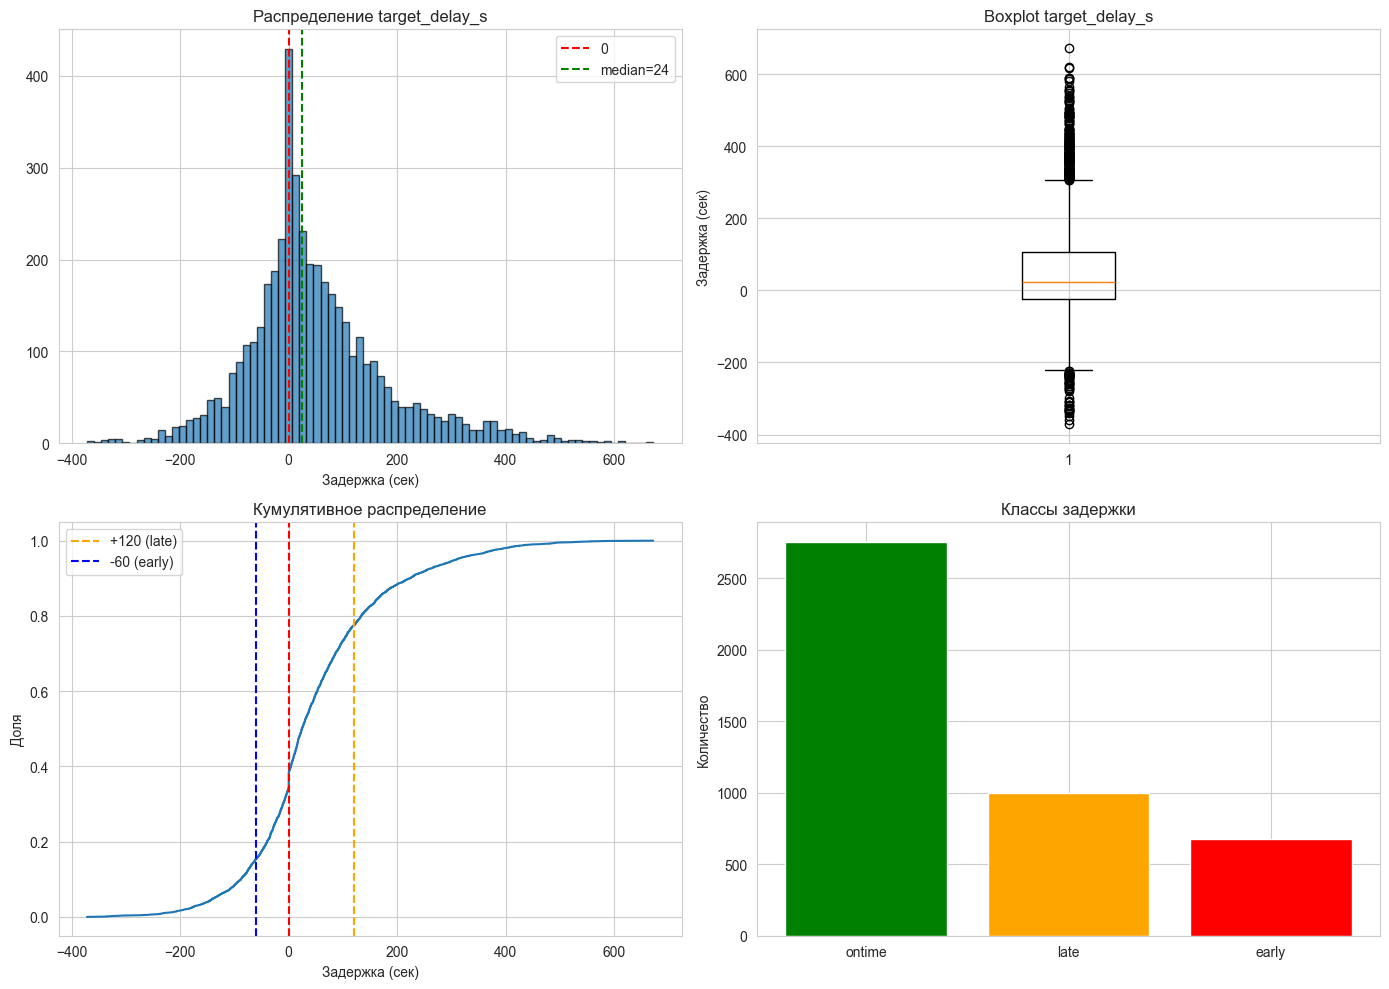

Статистика target_delay_s:
count   4434.00
mean      48.89
std      131.22
min     -372.00
25%      -25.00
50%       24.00
75%      107.00
max      672.00
Name: target_delay_s, dtype: float64

Проценты:
  1%: -230.7
  5%: -137.3
  25%: -25.0
  50%: 24.0
  75%: 107.0
  95%: 309.0
  99%: 448.3


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Гистограмма
axes[0, 0].hist(train_labels['target_delay_s'], bins=80, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(0, color='red', linestyle='--', label='0')
axes[0, 0].axvline(train_labels['target_delay_s'].median(), color='green', 
                   linestyle='--', label=f'median={train_labels["target_delay_s"].median():.0f}')
axes[0, 0].set_title('Распределение target_delay_s')
axes[0, 0].set_xlabel('Задержка (сек)')
axes[0, 0].legend()

# Boxplot
axes[0, 1].boxplot(train_labels['target_delay_s'].dropna())
axes[0, 1].set_title('Boxplot target_delay_s')
axes[0, 1].set_ylabel('Задержка (сек)')

# Кумулятивное распределение
sorted_vals = np.sort(train_labels['target_delay_s'].dropna())
axes[1, 0].plot(sorted_vals, np.arange(len(sorted_vals)) / len(sorted_vals))
axes[1, 0].set_title('Кумулятивное распределение')
axes[1, 0].set_xlabel('Задержка (сек)')
axes[1, 0].set_ylabel('Доля')
axes[1, 0].axvline(0, color='red', linestyle='--')
axes[1, 0].axvline(120, color='orange', linestyle='--', label='+120 (late)')
axes[1, 0].axvline(-60, color='blue', linestyle='--', label='-60 (early)')
axes[1, 0].legend()

# Классы
if 'target_class' in train_labels.columns:
    class_counts = train_labels['target_class'].value_counts()
    axes[1, 1].bar(class_counts.index, class_counts.values, color=['green', 'orange', 'red'])
    axes[1, 1].set_title('Классы задержки')
    axes[1, 1].set_ylabel('Количество')

plt.tight_layout()
plt.show()

print('Статистика target_delay_s:')
print(train_labels['target_delay_s'].describe())
print(f'\nПроценты:')
for p in [1, 5, 25, 50, 75, 95, 99]:
    print(f'  {p}%: {np.percentile(train_labels["target_delay_s"].dropna(), p):.1f}')

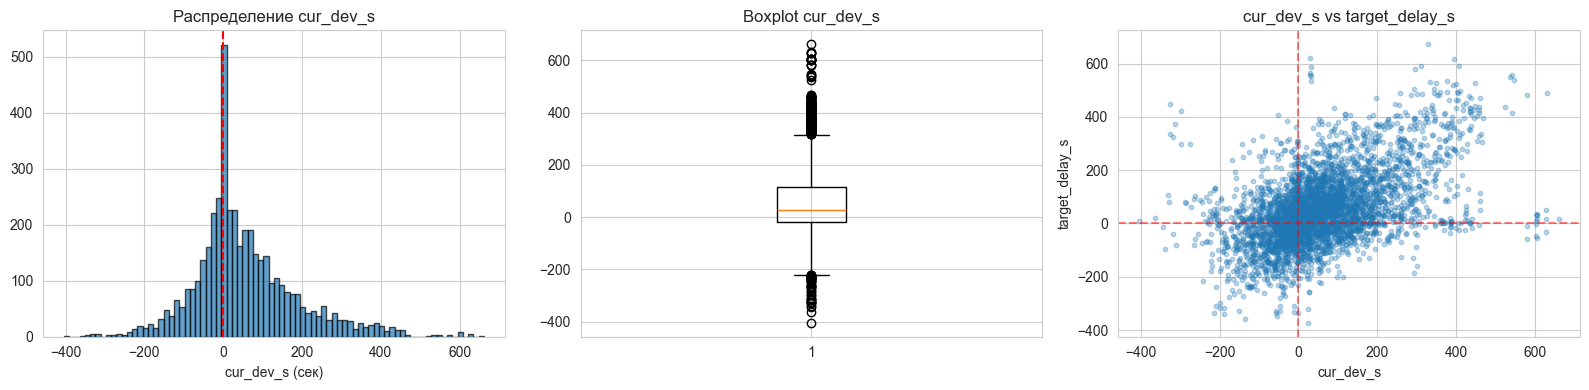

Статистика cur_dev_s:
count   4434.00
mean      54.75
std      132.09
min     -404.00
25%      -19.00
50%       26.00
75%      115.00
max      661.00
Name: cur_dev_s, dtype: float64

Корреляция cur_dev_s и target_delay_s: 0.511
MAE baseline (cur_dev_s): 93.03
MAE zero: 97.17


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(train_labels['cur_dev_s'], bins=80, edgecolor='black', alpha=0.7)
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('Распределение cur_dev_s')
axes[0].set_xlabel('cur_dev_s (сек)')

axes[1].boxplot(train_labels['cur_dev_s'].dropna())
axes[1].set_title('Boxplot cur_dev_s')

axes[2].scatter(train_labels['cur_dev_s'], train_labels['target_delay_s'], 
                alpha=0.3, s=10)
axes[2].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[2].axvline(0, color='red', linestyle='--', alpha=0.5)
axes[2].set_title('cur_dev_s vs target_delay_s')
axes[2].set_xlabel('cur_dev_s')
axes[2].set_ylabel('target_delay_s')

plt.tight_layout()
plt.show()

print('Статистика cur_dev_s:')
print(train_labels['cur_dev_s'].describe())
print(f'\nКорреляция cur_dev_s и target_delay_s: {train_labels["cur_dev_s"].corr(train_labels["target_delay_s"]):.3f}')
print(f'MAE baseline (cur_dev_s): {np.mean(np.abs(train_labels["target_delay_s"] - train_labels["cur_dev_s"])):.2f}')
print(f'MAE zero: {np.mean(np.abs(train_labels["target_delay_s"])):.2f}')

Обучаем модель CatBoost с реальными данными

In [15]:

from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GroupShuffleSplit
import warnings
warnings.filterwarnings('ignore')

RANDOM_SEED = 42

# ========== 1. ЗАГРУЗКА ==========
train = pd.read_csv(f'{DATA_DIR}/data_for_training/train_real.csv')
test = pd.read_csv(f'{DATA_DIR}/data_for_training/test_features_353.csv')
val = pd.read_csv(f'{DATA_DIR}/data_for_training/val_real.csv')

# Первая колонка — sample_id, но у неё может не быть названия
# Переименуем на всякий случай
for df in [train, test, val]:
    if df.columns[0] != 'sample_id':
        df.rename(columns={df.columns[0]: 'sample_id'}, inplace=True)

print('Train:', train.shape)
print('Test:', test.shape)
print('Val:', val.shape)
print('\nКолонки:', train.columns.tolist())

Train: (4251, 20)
Test: (353, 20)
Val: (1301, 20)

Колонки: ['sample_id', 'tr_id', 'T', 'target_stop_id', 'target_time_begin', 'target_stop_lon', 'target_stop_lat', 'time_to_target_s', 'last_message_age_s', 'last_speed_kmh', 'mean_speed_1m_kmh', 'mean_speed_3m_kmh', 'mean_speed_5m_kmh', 'speed_std_5m_kmh', 'speed_change_5m_kmh', 'stopped_share_5m', 'valid_messages_5m', 'distance_to_target_km', 'current_dev_s', 'target_delay_s']


In [11]:
# ========== 2. ОПРЕДЕЛЯЕМ КОЛОНКИ ==========
TARGET = 'target_delay_s'
ID_COL = 'sample_id'
GROUP_COL = 'tr_id'
CAT_FEATURES = ['tr_id', 'target_stop_id']

# Колонки, которые НЕ идут в модель (id, время, target)
DROP_COLS = [ID_COL, TARGET, 'T', 'target_time_begin']

# ========== 3. SPLIT + ОБУЧЕНИЕ ==========
y_full = train[TARGET].copy()
X_full = train.drop(columns=[c for c in DROP_COLS if c in train.columns]).copy()

# Split по tr_id
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_SEED)
train_idx, val_idx = next(gss.split(X_full, y_full, groups=X_full[GROUP_COL]))

X_train = X_full.iloc[train_idx].copy()
y_train = y_full.iloc[train_idx].copy()
X_val = X_full.iloc[val_idx].copy()
y_val = y_full.iloc[val_idx].copy()

# Убираем GROUP_COL? Нет, tr_id — категориальный признак, оставляем
print(f'Train: {X_train.shape}, Val: {X_val.shape}')
print(f'Признаки: {X_train.columns.tolist()}')

# CatBoost Pool
train_pool = Pool(X_train, y_train, cat_features=CAT_FEATURES)
val_pool = Pool(X_val, y_val, cat_features=CAT_FEATURES)

# Модель
model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='MAE',
    eval_metric='MAE',
    random_seed=RANDOM_SEED,
    verbose=100,
    early_stopping_rounds=50,
)

model.fit(train_pool, eval_set=val_pool, use_best_model=True)

# Метрика
y_pred_val = model.predict(X_val)
mae_val = mean_absolute_error(y_val, y_pred_val)

# Baseline: current_dev_s (с обработкой NaN)
baseline_pred = X_val['current_dev_s'].fillna(0)
mae_baseline = mean_absolute_error(y_val, baseline_pred)

# Zero baseline
mae_zero = mean_absolute_error(y_val, np.zeros(len(y_val)))

print(f'\nMAE model:    {mae_val:.2f}')
print(f'MAE baseline: {mae_baseline:.2f}')
print(f'MAE zero:     {mae_zero:.2f}')
print(f'Улучшение к baseline: {mae_baseline - mae_val:.2f} сек')

Train: (3073, 16), Val: (1178, 16)
Признаки: ['tr_id', 'target_stop_id', 'target_stop_lon', 'target_stop_lat', 'time_to_target_s', 'last_message_age_s', 'last_speed_kmh', 'mean_speed_1m_kmh', 'mean_speed_3m_kmh', 'mean_speed_5m_kmh', 'speed_std_5m_kmh', 'speed_change_5m_kmh', 'stopped_share_5m', 'valid_messages_5m', 'distance_to_target_km', 'current_dev_s']
0:	learn: 86.1068652	test: 97.9565353	best: 97.9565353 (0)	total: 190ms	remaining: 3m 10s
100:	learn: 63.2457621	test: 84.7847237	best: 84.7831829 (99)	total: 4.79s	remaining: 42.6s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 84.77552956
bestIteration = 101

Shrink model to first 102 iterations.

MAE model:    84.78
MAE baseline: 97.46
MAE zero:     101.53
Улучшение к baseline: 12.69 сек


In [16]:
# ========== 4. TEST ==========
y_test = test[TARGET].copy()
X_test = test.drop(columns=[c for c in DROP_COLS if c in test.columns]).copy()

y_pred_test = model.predict(X_test)
mae_test = mean_absolute_error(y_test, y_pred_test)

baseline_pred_test = X_test['current_dev_s'].fillna(0)
mae_baseline_test = mean_absolute_error(y_test, baseline_pred_test)
mae_zero_test = mean_absolute_error(y_test, np.zeros(len(y_test)))

print(f'MAE model on test:    {mae_test:.2f}')
print(f'MAE baseline on test: {mae_baseline_test:.2f}')
print(f'MAE zero on test:     {mae_zero_test:.2f}')

MAE model on test:    80.98
MAE baseline on test: 93.36
MAE zero on test:     103.34


Теперь то же самое, только для всех данных, включая синтетические


In [17]:
RANDOM_SEED = 42

# ========== 1. ЗАГРУЗКА ==========
train = pd.read_csv(f'{DATA_DIR}/data_for_training/train_all.csv')
test = pd.read_csv(f'{DATA_DIR}/data_for_training/test_features_353.csv')
val = pd.read_csv(f'{DATA_DIR}/data_for_training/val_all.csv')

# Первая колонка — sample_id, но у неё может не быть названия
# Переименуем на всякий случай
for df in [train, test, val]:
    if df.columns[0] != 'sample_id':
        df.rename(columns={df.columns[0]: 'sample_id'}, inplace=True)

print('Train:', train.shape)
print('Test:', test.shape)
print('Val:', val.shape)
print('\nКолонки:', train.columns.tolist())


# ========== 2. ОПРЕДЕЛЯЕМ КОЛОНКИ ==========
TARGET = 'target_delay_s'
ID_COL = 'sample_id'
GROUP_COL = 'tr_id'
CAT_FEATURES = ['tr_id', 'target_stop_id']

# Колонки, которые НЕ идут в модель (id, время, target)
DROP_COLS = [ID_COL, TARGET, 'T', 'target_time_begin']

# ========== 3. SPLIT + ОБУЧЕНИЕ ==========
y_full = train[TARGET].copy()
X_full = train.drop(columns=[c for c in DROP_COLS if c in train.columns]).copy()

# Split по tr_id
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_SEED)
train_idx, val_idx = next(gss.split(X_full, y_full, groups=X_full[GROUP_COL]))

X_train = X_full.iloc[train_idx].copy()
y_train = y_full.iloc[train_idx].copy()
X_val = X_full.iloc[val_idx].copy()
y_val = y_full.iloc[val_idx].copy()

# Убираем GROUP_COL? Нет, tr_id — категориальный признак, оставляем
print(f'Train: {X_train.shape}, Val: {X_val.shape}')
print(f'Признаки: {X_train.columns.tolist()}')

# CatBoost Pool
train_pool = Pool(X_train, y_train, cat_features=CAT_FEATURES)
val_pool = Pool(X_val, y_val, cat_features=CAT_FEATURES)

# Модель
model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='MAE',
    eval_metric='MAE',
    random_seed=RANDOM_SEED,
    verbose=100,
    early_stopping_rounds=50,
)

model.fit(train_pool, eval_set=val_pool, use_best_model=True)

# Метрика
y_pred_val = model.predict(X_val)
mae_val = mean_absolute_error(y_val, y_pred_val)

# Baseline: current_dev_s (с обработкой NaN)
baseline_pred = X_val['current_dev_s'].fillna(0)
mae_baseline = mean_absolute_error(y_val, baseline_pred)

# Zero baseline
mae_zero = mean_absolute_error(y_val, np.zeros(len(y_val)))

print(f'\nMAE model:    {mae_val:.2f}')
print(f'MAE baseline: {mae_baseline:.2f}')
print(f'MAE zero:     {mae_zero:.2f}')
print(f'Улучшение к baseline: {mae_baseline - mae_val:.2f} сек')

Train: (12702, 20)
Test: (353, 20)
Val: (3954, 20)

Колонки: ['sample_id', 'tr_id', 'T', 'target_stop_id', 'target_time_begin', 'target_stop_lon', 'target_stop_lat', 'time_to_target_s', 'last_message_age_s', 'last_speed_kmh', 'mean_speed_1m_kmh', 'mean_speed_3m_kmh', 'mean_speed_5m_kmh', 'speed_std_5m_kmh', 'speed_change_5m_kmh', 'stopped_share_5m', 'valid_messages_5m', 'distance_to_target_km', 'current_dev_s', 'target_delay_s']
Train: (10032, 16), Val: (2670, 16)
Признаки: ['tr_id', 'target_stop_id', 'target_stop_lon', 'target_stop_lat', 'time_to_target_s', 'last_message_age_s', 'last_speed_kmh', 'mean_speed_1m_kmh', 'mean_speed_3m_kmh', 'mean_speed_5m_kmh', 'speed_std_5m_kmh', 'speed_change_5m_kmh', 'stopped_share_5m', 'valid_messages_5m', 'distance_to_target_km', 'current_dev_s']
0:	learn: 92.4562191	test: 84.7443811	best: 84.7443811 (0)	total: 45.4ms	remaining: 45.4s
100:	learn: 67.0066568	test: 71.8580055	best: 71.8580055 (100)	total: 4.81s	remaining: 42.8s
200:	learn: 59.8051532	

In [18]:
# ========== 4. TEST ==========
y_test = test[TARGET].copy()
X_test = test.drop(columns=[c for c in DROP_COLS if c in test.columns]).copy()

y_pred_test = model.predict(X_test)
mae_test = mean_absolute_error(y_test, y_pred_test)

baseline_pred_test = X_test['current_dev_s'].fillna(0)
mae_baseline_test = mean_absolute_error(y_test, baseline_pred_test)
mae_zero_test = mean_absolute_error(y_test, np.zeros(len(y_test)))

print(f'MAE model on test:    {mae_test:.2f}')
print(f'MAE baseline on test: {mae_baseline_test:.2f}')
print(f'MAE zero on test:     {mae_zero_test:.2f}')

MAE model on test:    67.04
MAE baseline on test: 93.36
MAE zero on test:     103.34


Теперь пробую submission создать для проверки на системе


In [23]:
import pandas as pd

# Твой sample_submission
sub = pd.read_csv(f'{DATA_DIR}/sample_submission.csv', sep=';')

# Твои прогнозы (val с признаками)
# Проверяем, совпадает ли порядок sample_id
print('Порядок совпадает:', (val['sample_id'].values == sub['sample_id'].values).all())
print('Множества совпадают:', set(val['sample_id']) == set(sub['sample_id']))

ValueError: operands could not be broadcast together with shapes (3954,) (151,) 